In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [4]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df=df.drop(columns=[
'Row ID',
'Order ID',
'Customer ID',
'Customer Name',
'Product ID',
'Product Name',
'Postal Code',
'Country'
])

In [12]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [14]:
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Quarter'] = df['Order Date'].dt.quarter
df['High_Discount'] = (df['Discount'] > 0.20).astype(int)

In [15]:
df = df.drop(columns=['Order Date', 'Ship Date'])

In [25]:
df.head()

,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Shipping_Days,Order_Year,Order_Month,Order_Quarter,Profit_Margin,Is_Loss,High_Discount
0,2,0,194,15,2,0,4,261.9600,2,0.00,41.9136,3,2016,11,4,0.1600,0,0
1,2,0,194,15,2,0,5,731.9400,3,0.00,219.5820,3,2016,11,4,0.3000,0,0
2,2,1,266,3,3,1,10,14.6200,2,0.00,6.8714,4,2016,6,2,0.4700,0,0
3,3,0,153,8,2,0,16,957.5775,5,0.45,-383.0310,7,2015,10,4,-0.4000,1,1
4,3,0,153,8,2,1,14,22.3680,2,0.20,2.5164,7,2015,10,4,0.1125,0,0


In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['Ship Mode', 'Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [43]:
X = df.drop(['Profit', 'Profit_Margin', 'Is_Loss'], axis=1)
y = df['Profit']

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [46]:
lr = LinearRegression()

In [47]:
lr.fit(X_train, y_train)

LinearRegression()

In [48]:
y_pred = lr.predict(X_test)

In [49]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.7000208955376579
MAE: 70.12738146597444
RMSE: 287.098810378197


In [50]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [51]:
lasso = Lasso(alpha=0.1)

In [52]:
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [53]:
y_pred_lasso = lasso.predict(X_test)

print(y_pred_lasso)

[111.93409586  13.15439101   7.10210406 ...  -8.97565609   5.96456834
 -59.72070847]


In [54]:
print("Lasso Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso Regression Results
R2 Score: -0.7004044873179887
MAE: 70.00069709132144
RMSE: 287.1311989601393


In [55]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lasso
})

print(result.head(10))

       Actual   Predicted
3125  21.1428  111.934096
1441  11.4600   13.154391
4510  17.1580    7.102104
39   -15.1470  -66.748839
4509  -6.4233  -17.860954
1599   8.6744   38.862966
7363 -73.7061  -52.851070
9951   8.6900   52.357043
500  -15.0800 -132.207132
4847  17.9080  -37.656071


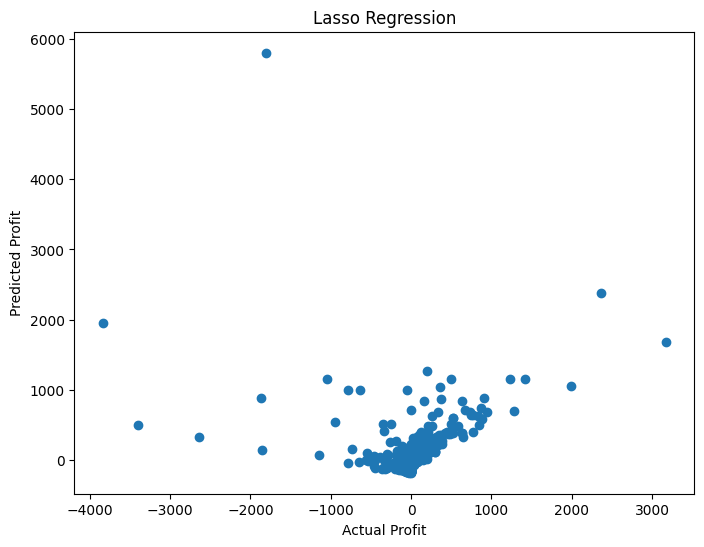

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Lasso Regression")
plt.show()

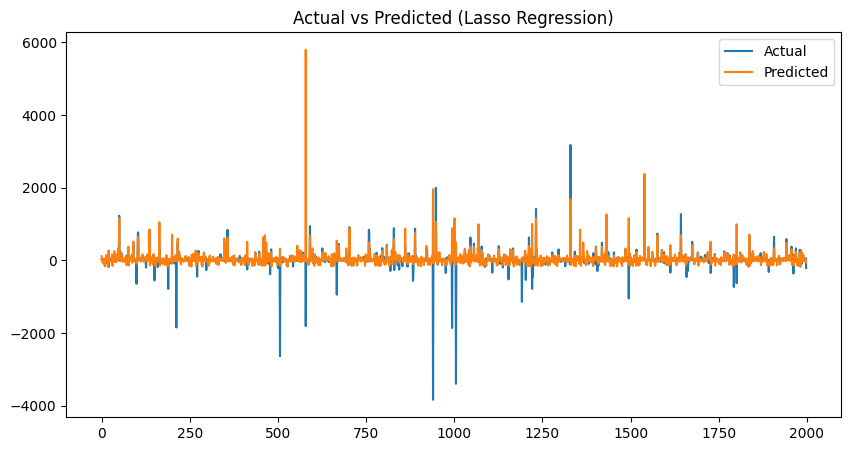

In [57]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lasso, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (Lasso Regression)")
plt.show()

In [59]:
new_data = pd.DataFrame({
    'Ship Mode': [2],
    'Segment': [1],
    'City': [45],
    'State': [10],
    'Region': [2],
    'Category': [1],
    'Sub-Category': [5],
    'Sales': [3000],      # Sales = 3000
    'Quantity': [5],
    'Discount': [0.10],
    'Shipping_Days': [4],
    'Order_Year': [2017],
    'Order_Month': [11],
    'Order_Quarter': [4],
    'High_Discount': [0]
})

prediction = lasso.predict(new_data)

print("Predicted Profit =", prediction[0])

Predicted Profit = 785.0863994844981


In [60]:
prediction = lasso.predict(new_data)
print("Predicted Profit =", prediction[0])

Predicted Profit = 785.0863994844981
